# Some remarks on my project

## First:
I know that the competition asked to make Linera regression only but I added also polynomial regression and make a final pipline for both to get the best Result 

## second:
### 1.I make linear regression 
### 2. then polynomial regression 
### 3. then combine them in one pipeline and make voting to get the best result 
### 4. and you will notice that when I make linear and polynomuial regression separately the error of polynomial is little bit smaller than linear
### 5. so when I put them in one pipleline and use voting it gives me best result than using each separately 
### 6.and at end I make some different visualization using different library (bokeh) instead using the traditional ones (Matplot , sns ) that gives interactive visualization , that you can know the name of any dot at regression by just clicking on it

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import plotly.express as px
import re
from bokeh.plotting import figure, show , output_notebook
from bokeh.io import output_notebook, show
from bokeh.models import ColumnDataSource,  DataTable , TableColumn,HTMLTemplateFormatter,HoverTool, Select, CustomJS , LinearColorMapper, ColorBar, BasicTicker

from bokeh.layouts import column
 
 
from bokeh.transform import transform
from bokeh.palettes import RdBu


output_notebook()  
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8') 

Loading BokehJS ...

In [2]:
train=pd.read_csv('train.csv')
test=pd.read_csv('test.csv')

In [3]:
train_raw = train.copy()
test_raw = test.copy()

In [4]:
train .info()

<class 'pandas.DataFrame'>
RangeIndex: 43584 entries, 0 to 43583
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        43584 non-null  str    
 1   player_id                 43584 non-null  str    
 2   player_name               43584 non-null  str    
 3   age                       43584 non-null  int64  
 4   nationality               43584 non-null  str    
 5   team                      43584 non-null  str    
 6   jersey_number             43584 non-null  int64  
 7   position                  43584 non-null  str    
 8   height_cm                 43584 non-null  int64  
 9   weight_kg                 43584 non-null  int64  
 10  preferred_foot            43584 non-null  str    
 11  club_name                 43584 non-null  str    
 12  market_value_eur          43584 non-null  int64  
 13  match_id                  43584 non-null  str    
 14  match_date       

In [5]:
train.describe()

,age,jersey_number,height_cm,weight_kg,market_value_eur,goals_team,goals_opponent,minutes_played,goals,assists,...,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards
count,43584.000000,43584.000000,43584.000000,43584.000000,4.358400e+04,43584.000000,43584.000000,43584.000000,43584.000000,43584.000000,...,43584.000000,43584.000000,43584.000000,43584.000000,43584.000000,43584.000000,43584.000000,43584.000000,43584.000000,43584.000000
mean,26.414648,13.472215,181.582760,75.814244,2.062389e+07,1.330213,1.330396,35.959090,0.055410,0.051946,...,53.100613,2.873591,60.712973,46.382517,64.214021,55.653391,0.641176,0.607402,272.246077,0.030745
std,4.036415,7.482398,6.332509,3.910184,2.752584e+07,1.147894,1.147741,36.399005,0.251703,0.237985,...,24.053829,4.265413,20.354651,22.706165,20.036176,13.683625,1.095840,0.930966,116.874543,0.207737
min,17.000000,1.000000,163.000000,65.000000,5.288220e+05,0.000000,0.000000,0.000000,0.000000,0.000000,...,5.000000,0.000000,15.000000,5.000000,25.000000,15.000000,0.000000,0.000000,0.000000,0.000000
25%,24.000000,7.000000,177.000000,73.000000,4.611388e+06,0.000000,0.000000,0.000000,0.000000,0.000000,...,33.300000,0.000000,43.900000,29.800000,46.700000,46.400000,0.000000,0.000000,184.000000,0.000000
50%,26.000000,13.000000,182.000000,76.000000,1.042809e+07,1.000000,1.000000,24.000000,0.000000,0.000000,...,50.300000,1.100000,57.400000,40.600000,61.700000,55.100000,0.000000,0.000000,267.000000,0.000000
75%,29.000000,20.000000,186.000000,78.000000,2.466088e+07,2.000000,2.000000,75.000000,0.000000,0.000000,...,72.100000,4.100000,75.900000,59.600000,79.725000,63.900000,1.000000,1.000000,359.000000,0.000000
max,39.000000,26.000000,200.000000,85.000000,2.000000e+08,7.000000,7.000000,90.000000,4.000000,3.000000,...,99.000000,37.000000,99.000000,99.000000,99.000000,99.000000,10.000000,8.000000,615.000000,4.000000


In [6]:
train.dtypes

Id                              str
player_id                       str
player_name                     str
age                           int64
nationality                     str
                             ...   
clutch_performance_score    float64
total_goals_tournament        int64
total_assists_tournament      int64
total_minutes_tournament      int64
player_of_match_awards        int64
Length: 75, dtype: object

In [7]:
train = train.drop(columns=['performance_score'])
test = test.drop(columns=['performance_score'])

In [8]:
missing=train.isnull().sum()
missing_pre=(missing/len(train))*100
pd.DataFrame({
    'Missing': missing,
    'Missing%':missing_pre.round(2)
})

,Missing,Missing%
Id,0,0.0
player_id,0,0.0
player_name,0,0.0
age,0,0.0
nationality,0,0.0
...,...,...
clutch_performance_score,0,0.0
total_goals_tournament,0,0.0
total_assists_tournament,0,0.0
total_minutes_tournament,0,0.0


In [9]:
missing=test.isnull().sum()
missing_pre=(missing/len(test))*100
pd.DataFrame({
    'Missing': missing,
    'Missing%':missing_pre.round(2)
})

,Missing,Missing%
Id,0,0.0
player_id,0,0.0
player_name,0,0.0
age,0,0.0
nationality,0,0.0
...,...,...
clutch_performance_score,0,0.0
total_goals_tournament,0,0.0
total_assists_tournament,0,0.0
total_minutes_tournament,0,0.0


<Axes: >

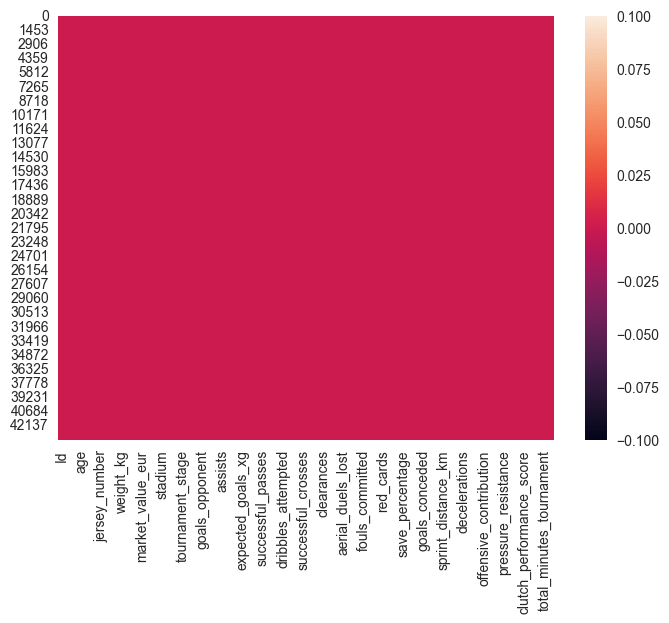

In [10]:
sns.heatmap(train.isnull())

<Axes: >

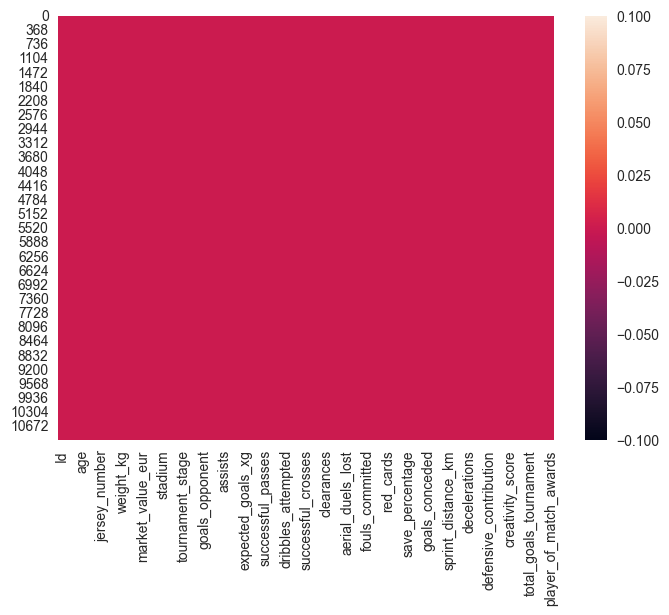

In [11]:
sns.heatmap(test.isnull())

In [12]:
train.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
43579    False
43580    False
43581    False
43582    False
43583    False
Length: 43584, dtype: bool

In [13]:
train.nunique()

Id                          43584
player_id                     998
player_name                   995
age                            23
nationality                    48
                            ...  
clutch_performance_score      823
total_goals_tournament         11
total_assists_tournament        9
total_minutes_tournament      582
player_of_match_awards          5
Length: 74, dtype: int64

In [14]:
cols = train.select_dtypes('object').columns
for col in cols:
    print(f"--- {col} ---")
    print(train[col].value_counts())
    print("-" * 20)

--- Id ---
Id
M00001_P00053    1
M00001_P00054    1
M00001_P00056    1
M00001_P00058    1
M00001_P00060    1
                ..
M01050_P01033    1
M01050_P01035    1
M01050_P01036    1
M01050_P01039    1
M01050_P01040    1
Name: count, Length: 43584, dtype: int64
--------------------
--- player_id ---
player_id
P00937    66
P00938    66
P00939    66
P00941    66
P00942    66
          ..
P00332    33
P00335    33
P00336    33
P00337    33
P00338    33
Name: count, Length: 998, dtype: int64
--------------------
--- player_name ---
player_name
Pierre-Emile Christensen     86
Kalidou Mendy                76
Hee-chan Hwang               68
Akram Ali                    66
Almoez Boudiaf               66
                             ..
Xaver Sabitzer               33
Marko Kick                   33
Konrad Sabitzer              33
Stefan Lainer                33
Maximilian Baumgartlinger    33
Name: count, Length: 995, dtype: int64
--------------------
--- nationality ---
nationality
Jamaican

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27912\447039567.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols = train.select_dtypes('object').columns


In [15]:
train.head()

,Id,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,...,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards
0,M00001_P00053,P00053,Pedro Gavi,36,Spanish,Spain,1,Goalkeeper,191,80,...,50.8,0.0,38.6,28.6,31.4,65.4,0,0,67,0
1,M00001_P00054,P00054,Gavi Morata,27,Spanish,Spain,2,Goalkeeper,190,75,...,55.6,0.0,35.7,29.8,46.2,47.8,0,0,392,0
2,M00001_P00056,P00056,Pedro Torres,24,Spanish,Spain,4,Defender,176,78,...,70.5,6.4,52.7,31.3,68.3,59.2,0,0,324,0
3,M00001_P00058,P00058,Rodri Laporte,27,Spanish,Spain,6,Defender,188,80,...,85.6,6.4,48.7,15.3,61.8,55.1,0,1,264,0
4,M00001_P00060,P00060,Ferran Pau,35,Spanish,Spain,8,Defender,179,72,...,37.5,0.0,47.3,34.3,45.3,44.3,0,0,167,0


In [16]:
train.drop_duplicates()

,Id,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,...,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards
0,M00001_P00053,P00053,Pedro Gavi,36,Spanish,Spain,1,Goalkeeper,191,80,...,50.8,0.0,38.6,28.6,31.4,65.4,0,0,67,0
1,M00001_P00054,P00054,Gavi Morata,27,Spanish,Spain,2,Goalkeeper,190,75,...,55.6,0.0,35.7,29.8,46.2,47.8,0,0,392,0
2,M00001_P00056,P00056,Pedro Torres,24,Spanish,Spain,4,Defender,176,78,...,70.5,6.4,52.7,31.3,68.3,59.2,0,0,324,0
3,M00001_P00058,P00058,Rodri Laporte,27,Spanish,Spain,6,Defender,188,80,...,85.6,6.4,48.7,15.3,61.8,55.1,0,1,264,0
4,M00001_P00060,P00060,Ferran Pau,35,Spanish,Spain,8,Defender,179,72,...,37.5,0.0,47.3,34.3,45.3,44.3,0,0,167,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43579,M01050_P01033,P01033,Ferland Seck,23,Senegalese,Senegal,19,Midfielder,185,79,...,38.2,3.6,49.1,53.1,44.0,60.6,0,1,162,0
43580,M01050_P01035,P01035,Sadio Diouf,24,Senegalese,Senegal,21,Forward,180,71,...,19.5,9.9,84.3,72.2,70.4,72.6,3,4,345,0
43581,M01050_P01036,P01036,Kalidou Faye,25,Senegalese,Senegal,22,Forward,165,66,...,24.7,0.0,36.4,30.8,58.3,25.1,2,1,127,0
43582,M01050_P01039,P01039,Boulaye Mendy,24,Senegalese,Senegal,25,Forward,180,77,...,21.7,5.3,74.2,76.7,67.9,38.1,1,0,276,0


In [17]:
numerical_col=train.select_dtypes(include='number')

In [18]:
target_col = 'player_rating'  
corr_series = train.corr(numeric_only=True)[target_col].drop(target_col)
corr_series = corr_series.reindex(corr_series.abs().sort_values(ascending=False).index)

# مافيش top_n خالص - خدي كل الأعمدة
corr_all = corr_series

source = ColumnDataSource(data=dict(
    feature=corr_all.index.tolist(),
    target=[target_col] * len(corr_all),
    corr=corr_all.values
))

mapper = LinearColorMapper(palette=list(reversed(RdBu[11])), low=-1, high=1)

p = figure(
    title=f"All Features Correlated with {target_col}",
    y_range=corr_all.index.tolist(),
    x_range=[target_col],
    width=450, height=1000,   # كبّرت الـ height عشان الأعمدة كتير دلوقتي
    toolbar_location=None,
    tools="hover", tooltips=[('Feature', '@feature'), ('Correlation', '@corr{0.00}')]
)

p.rect(x='target', y='feature', width=1, height=1, source=source,
       fill_color=transform('corr', mapper), line_color=None)

color_bar = ColorBar(color_mapper=mapper, ticker=BasicTicker(desired_num_ticks=8),
                      label_standoff=6, border_line_color=None, location=(0, 0))
p.add_layout(color_bar, 'right')

p.axis.major_label_text_font_size = "8pt"   # صغّرت الخط شوية عشان الأسامي متتلخبطش
p.xaxis.major_label_orientation = 1.0

show(p)

In [19]:
 
target_col = 'player_rating'  
corr_series = train.corr(numeric_only=True)[target_col].drop(target_col)
corr_series = corr_series.reindex(corr_series.abs().sort_values(ascending=False).index)
 
top_n = 15
corr_top = corr_series.head(top_n)
 
source = ColumnDataSource(data=dict(
    feature=corr_top.index.tolist(),
    target=[target_col] * len(corr_top),
    corr=corr_top.values
))

mapper = LinearColorMapper(palette=list(reversed(RdBu[11])), low=-1, high=1)

p = figure(
    title=f"Top {top_n} Features Correlated with {target_col}",
    y_range=corr_top.index.tolist(),
    x_range=[target_col],
    width=400, height=600,
    toolbar_location=None,
    tools="hover", tooltips=[('Feature', '@feature'), ('Correlation', '@corr{0.00}')]
)

p.rect(x='target', y='feature', width=1, height=1, source=source,
       fill_color=transform('corr', mapper), line_color=None)

color_bar = ColorBar(color_mapper=mapper, ticker=BasicTicker(desired_num_ticks=8),
                      label_standoff=6, border_line_color=None, location=(0, 0))
p.add_layout(color_bar, 'right')

p.axis.major_label_text_font_size = "10pt"
p.xaxis.major_label_orientation = 1.0

show(p)

In [20]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return outliers, lower_bound, upper_bound

 

In [21]:
outlier_summary = {}
for col in numerical_col:
    outliers, low, high = detect_outliers_iqr(train, col)
    outlier_summary[col] = len(outliers)

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['outlier_count'])
outlier_df.sort_values('outlier_count', ascending=False)

,outlier_count
fouls_suffered,10355
expected_assists_xa,8784
expected_goals_xg,7585
blocks,7418
clearances,5357
successful_dribbles,5239
tackles,5214
yellow_cards,4274
aerial_duels_won,4105
market_value_eur,4033


In [22]:
numerical_col_filtered = [c for c in numerical_col if c != 'player_rating']

outlier_summary = {}
for col in numerical_col_filtered:
    outliers, low, high = detect_outliers_iqr(test, col)
    outlier_summary[col] = len(outliers)

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['outlier_count'])
outlier_df.sort_values('outlier_count', ascending=False)

,outlier_count
fouls_suffered,2710
expected_assists_xa,2276
expected_goals_xg,1982
blocks,1928
successful_dribbles,1357
market_value_eur,1351
clearances,1349
tackles,1326
aerial_duels_won,1117
yellow_cards,1072


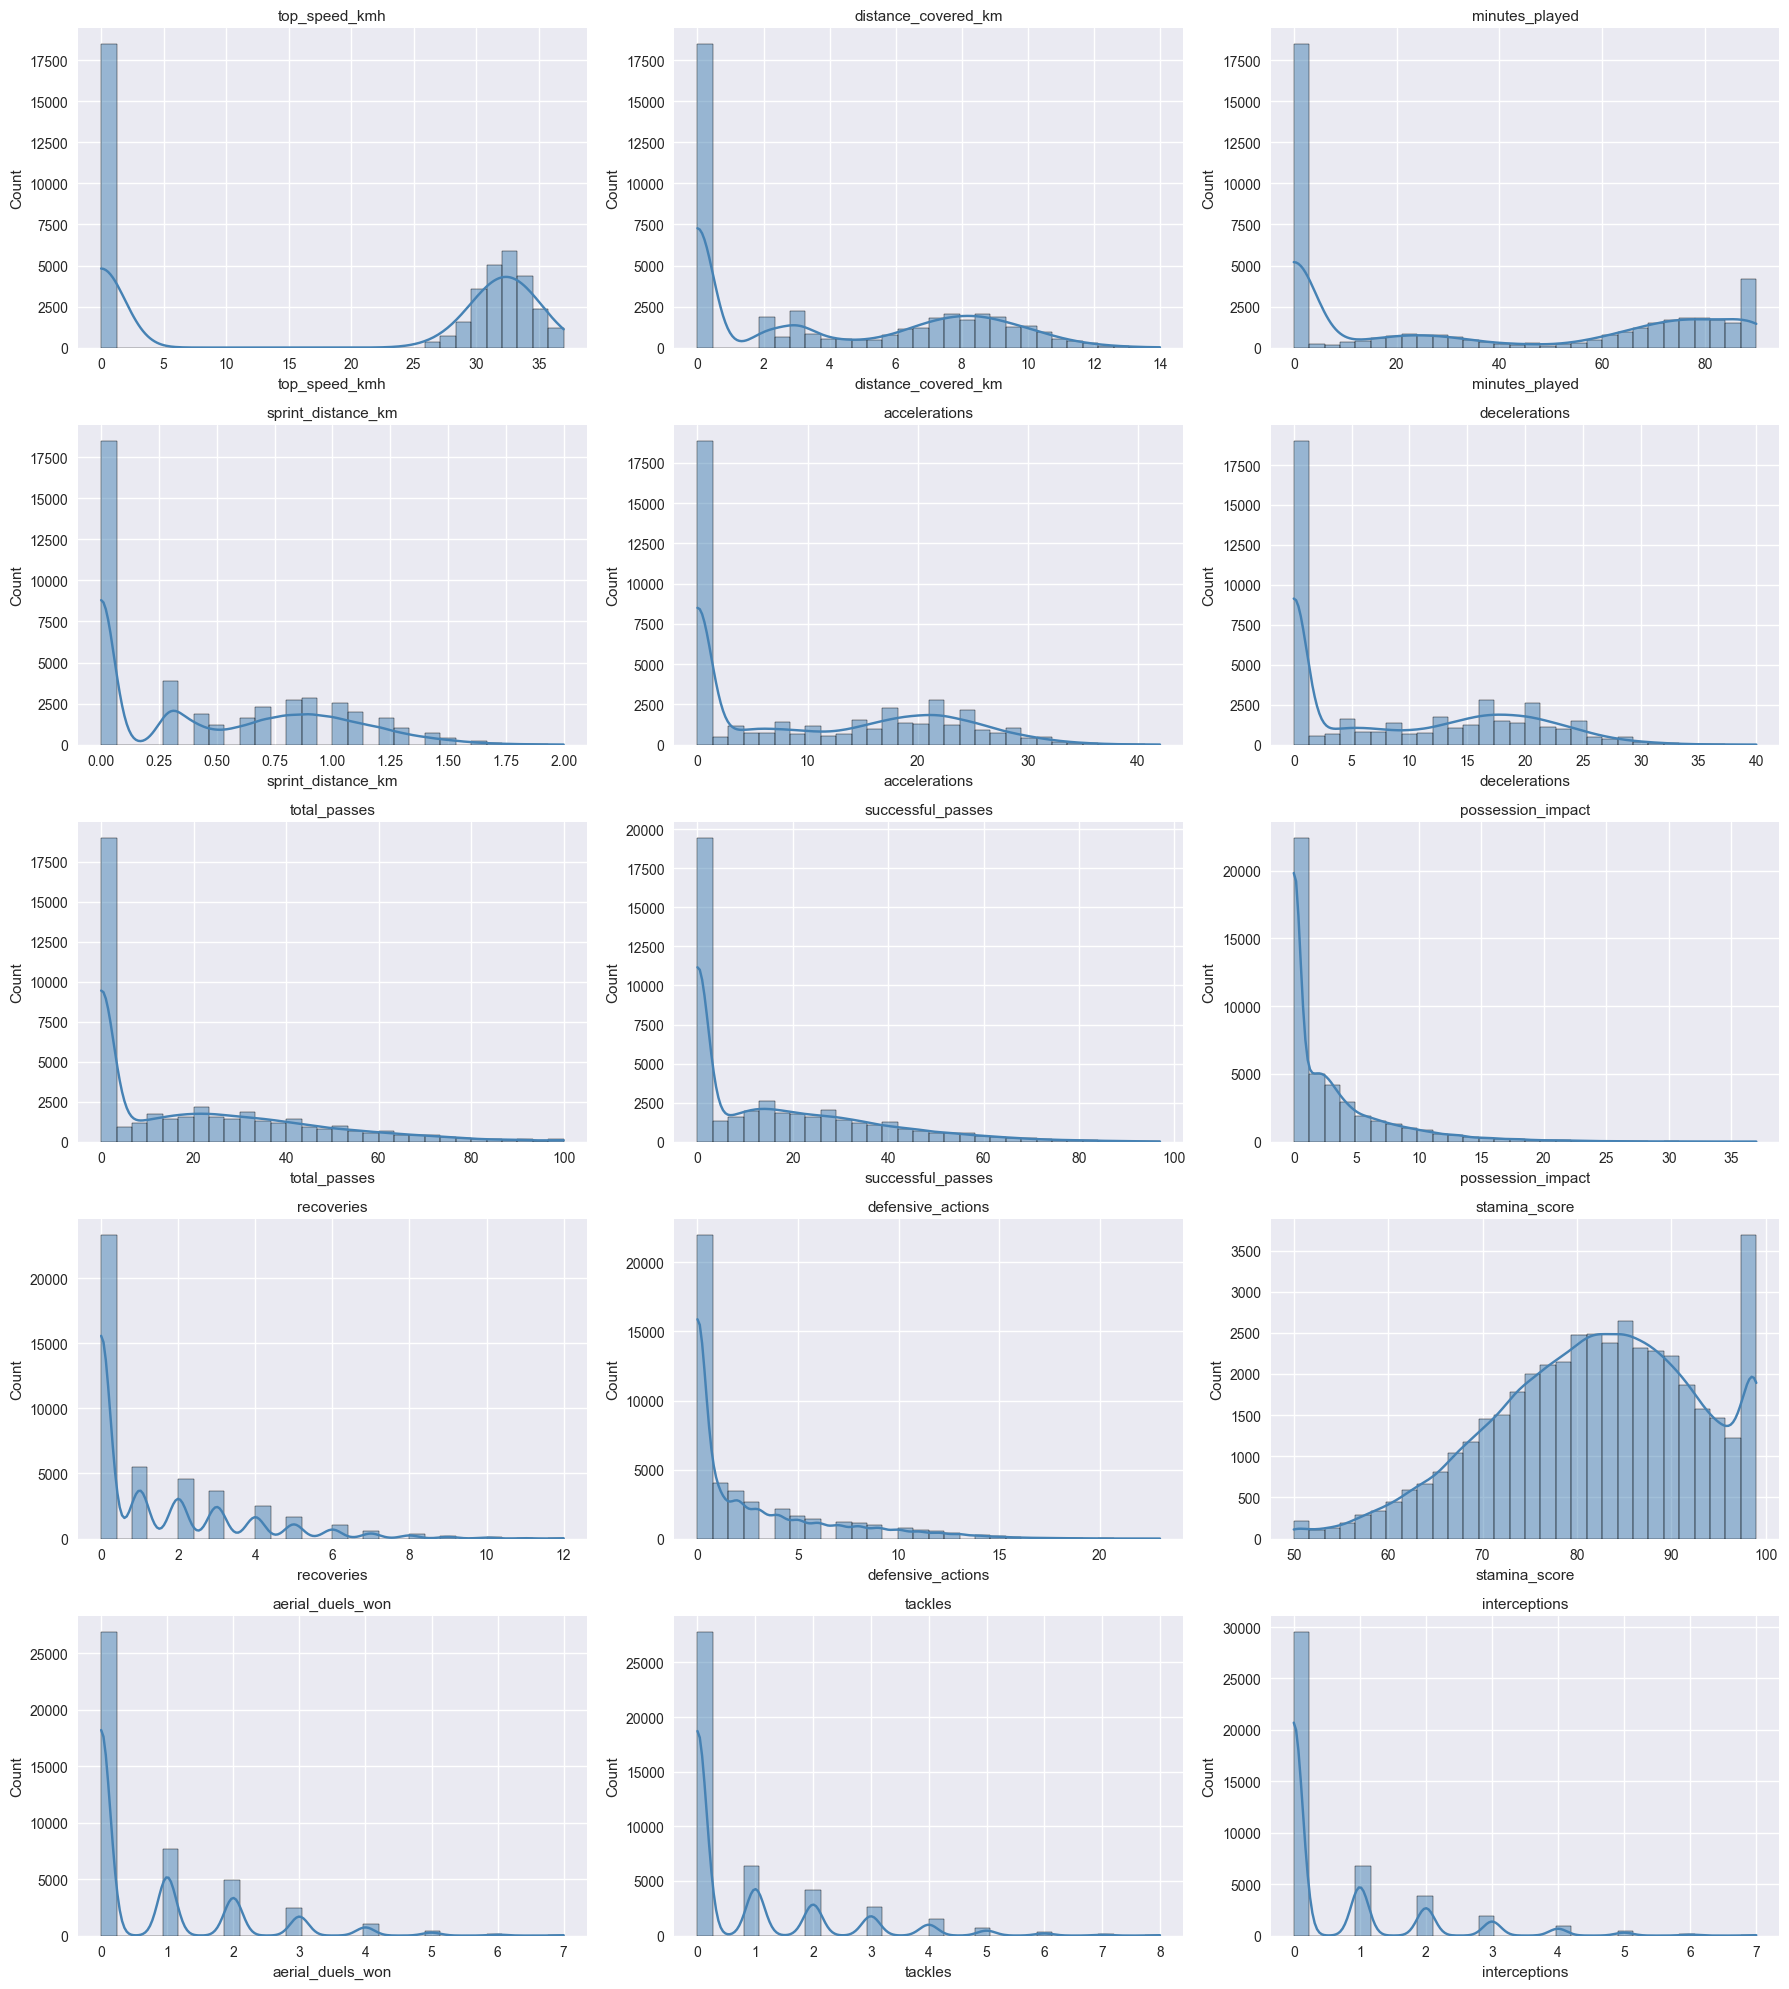

In [23]:
 

top_15_features = corr_top.index.tolist()

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(top_15_features):
    sns.histplot(train[col].dropna(), bins=30, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=11)

for j in range(len(top_15_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [24]:
categorical_cols = train.select_dtypes(include=['object', 'category']).columns.tolist()
 

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27912\2529765244.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train.select_dtypes(include=['object', 'category']).columns.tolist()


In [25]:
# افصلي الأعمدة اللي فعلاً تصلح للـ countplot (أقل من 15 فئة مثلاً)
low_card_cols = [col for col in categorical_cols if train[col].nunique() <= 15]
high_card_cols = [col for col in categorical_cols if train[col].nunique() > 15]

print("Low cardinality  :", low_card_cols)
print("High cardinality :", high_card_cols)
 

Low cardinality  : ['position', 'preferred_foot', 'tournament_stage', 'match_result']
High cardinality : ['Id', 'player_id', 'player_name', 'nationality', 'team', 'club_name', 'match_id', 'match_date', 'stadium', 'city', 'opponent_team']


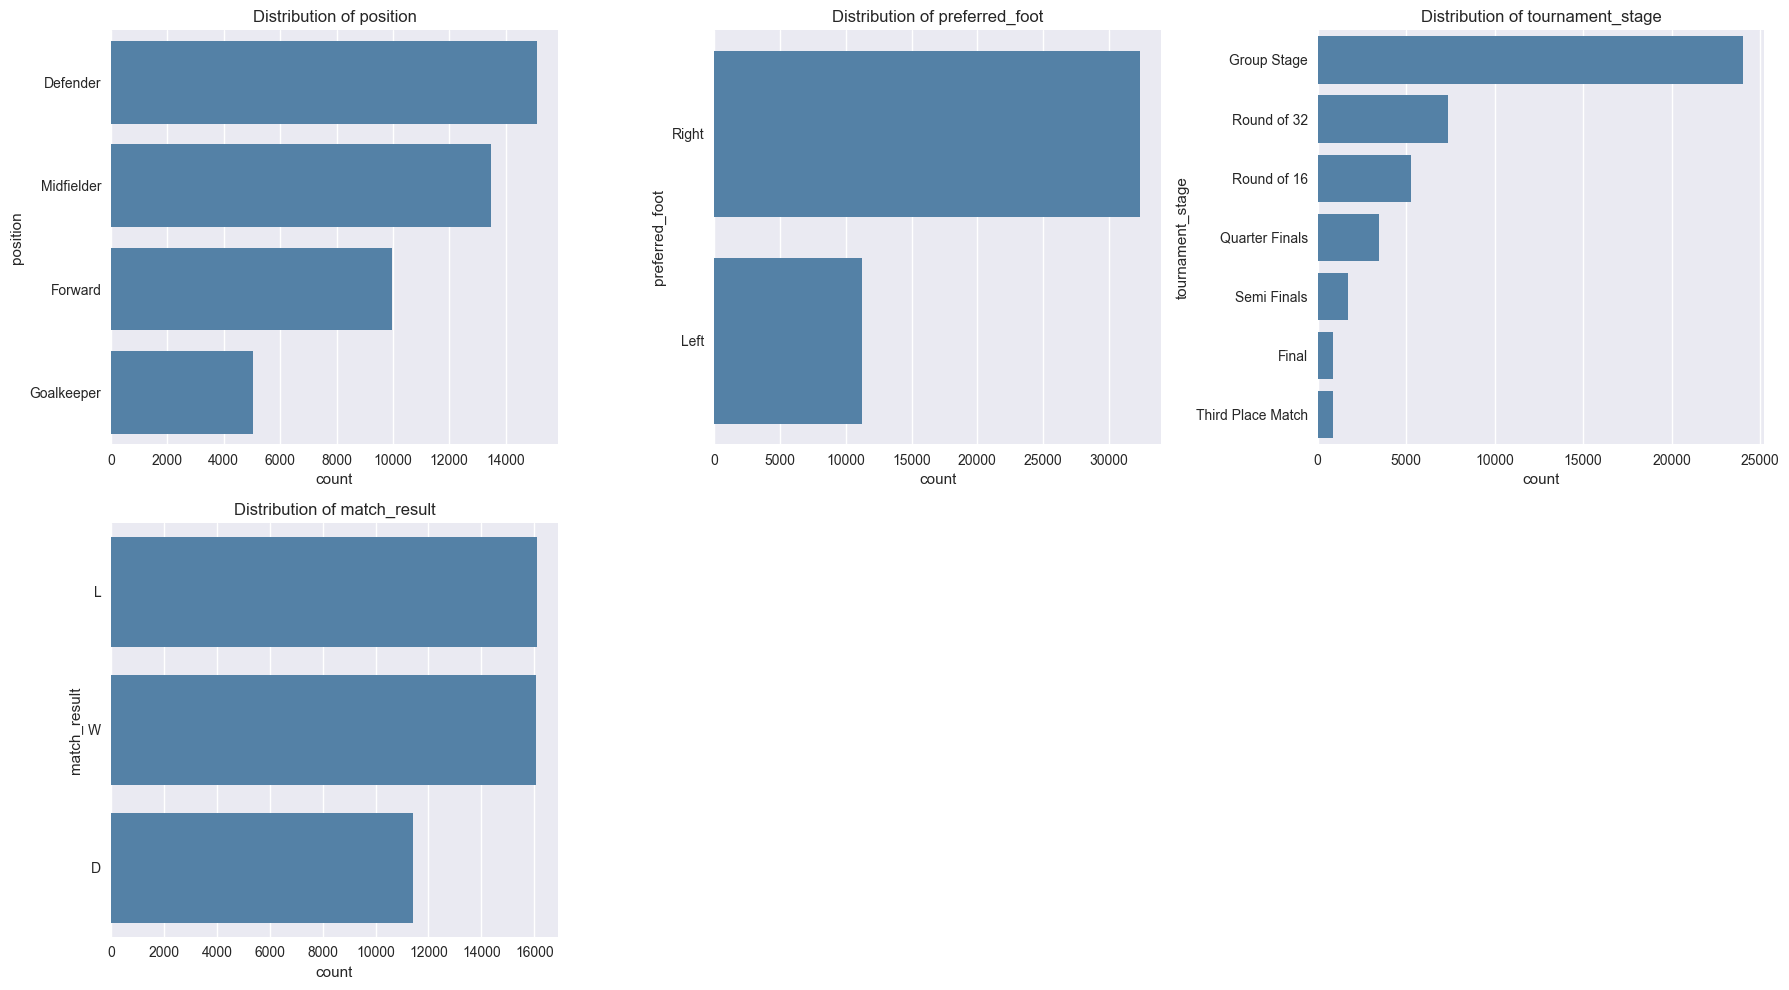

In [26]:
n_cols = len(low_card_cols)
fig, axes = plt.subplots(nrows=(n_cols // 3) + 1, ncols=3, figsize=(18, 5 * ((n_cols // 3) + 1)))
axes = axes.flatten()

for i, col in enumerate(low_card_cols):
    sns.countplot(y=train[col], order=train[col].value_counts().index, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')

for j in range(len(low_card_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

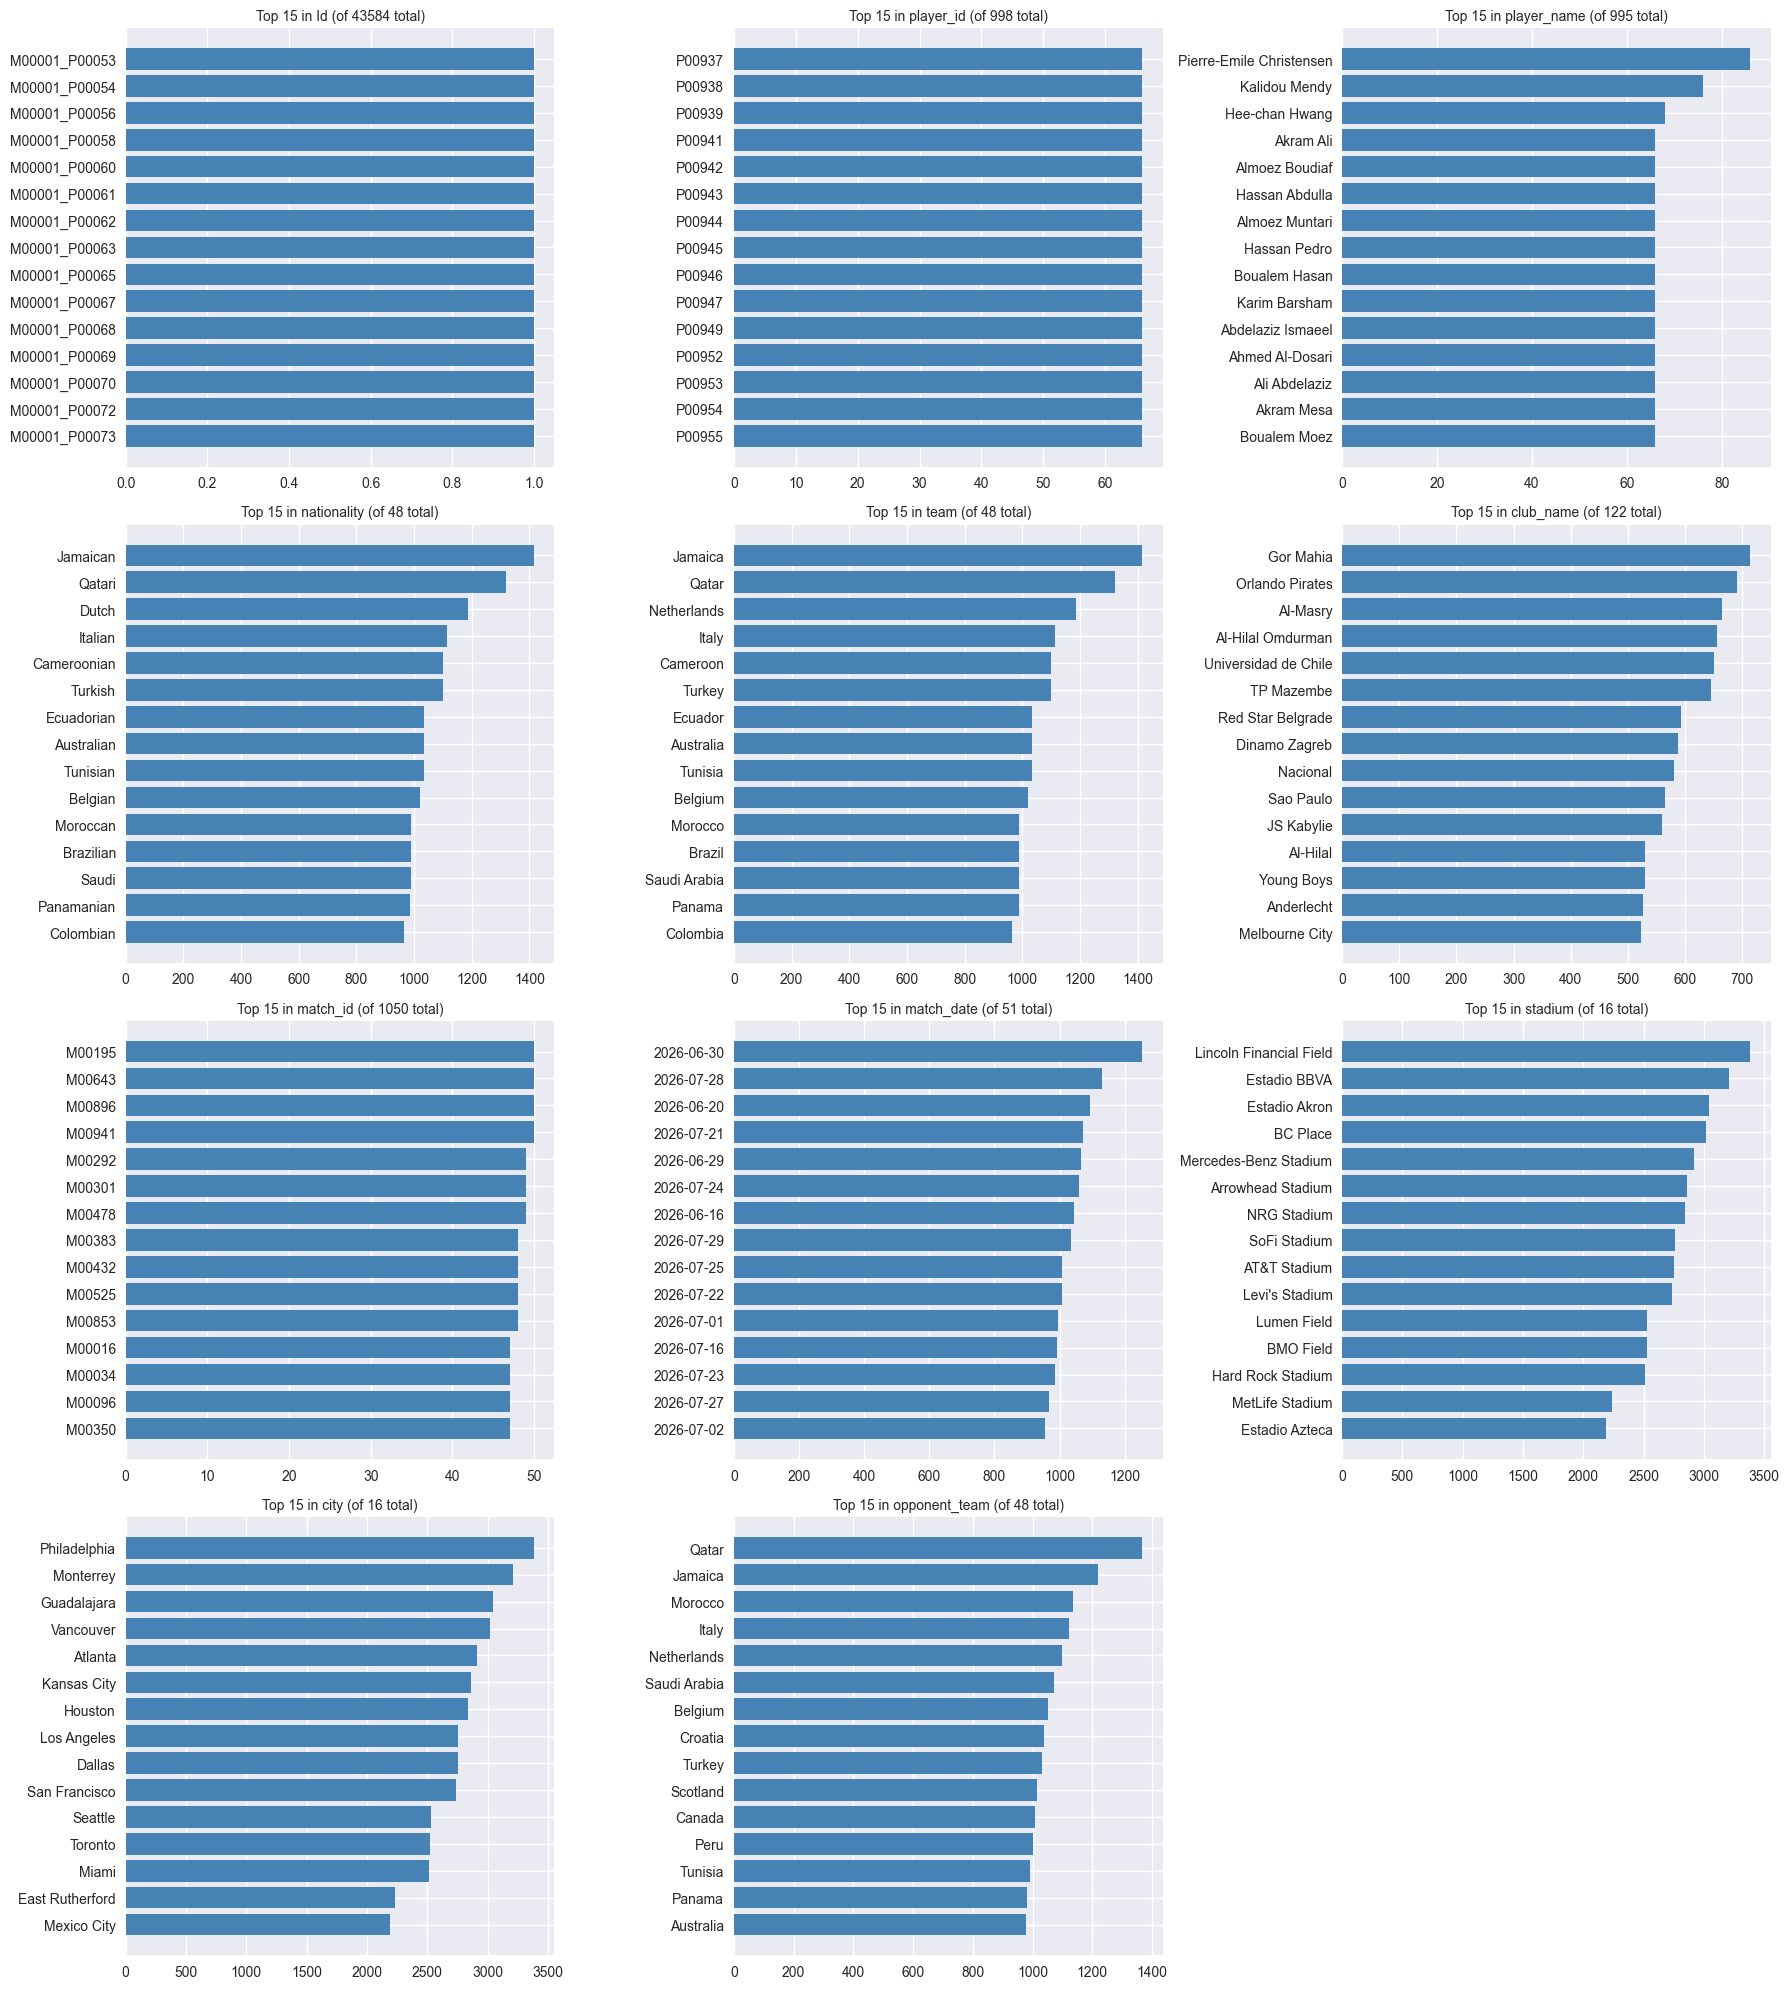

In [27]:
n_cols_grid = 3
n_rows = (len(high_card_cols) // n_cols_grid) + (1 if len(high_card_cols) % n_cols_grid else 0)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols_grid, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(high_card_cols):
    top_n = train[col].value_counts().head(15)
    axes[i].barh(top_n.index, top_n.values, color='steelblue')
    axes[i].set_title(f'Top 15 in {col} (of {train[col].nunique()} total)', fontsize=10)
    axes[i].invert_yaxis() 

 
for j in range(len(high_card_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Feature Selection & Cleanup

In [28]:
target_col = 'player_rating'
test_ids = test['Id'].copy()

drop_cols = ['Id', 'player_id', 'player_name', 'match_id', 'match_date', 'stadium', 'city',
             'nationality', 'team', 'club_name', 'opponent_team',
             'age', 'height_cm', 'weight_kg', 'market_value_eur', 'jersey_number']

train = train.drop(columns=[c for c in drop_cols if c in train.columns])
test = test.drop(columns=[c for c in drop_cols if c in test.columns])

train.shape, test.shape

((43584, 58), (11016, 57))

## Outlier Handling (IQR Capping, bounds from train only)

In [29]:
def cap_outliers_train_test(train, test, col):
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    train[col] = train[col].clip(lower, upper)
    if col in test.columns:
        test[col] = test[col].clip(lower, upper)
    return train, test

numerical_features_all = [c for c in train.select_dtypes(include=np.number).columns if c != target_col]

for col in numerical_features_all:
    train, test = cap_outliers_train_test(train, test, col)

## Train / Target Split

In [30]:
X = train.drop(columns=[target_col])
y = train[target_col]

categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

len(categorical_features), len(numerical_features)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27912\346055340.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()


(4, 53)

## Feature Groups for Polynomial Expansion

In [31]:
corr_with_target = X[numerical_features].corrwith(y).abs().sort_values(ascending=False)
poly_features_list = corr_with_target.head(12).index.tolist()
linear_only_features = [c for c in numerical_features if c not in poly_features_list]

poly_features_list

c:\Users\LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


['top_speed_kmh',
 'distance_covered_km',
 'minutes_played',
 'sprint_distance_km',
 'accelerations',
 'decelerations',
 'total_passes',
 'successful_passes',
 'possession_impact',
 'recoveries',
 'defensive_actions',
 'aerial_duels_won']

## Preprocessing Pipelines

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

preprocessor_linear = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

poly_numeric_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

preprocessor_poly = ColumnTransformer([
    ('poly_num', poly_numeric_pipeline, poly_features_list),
    ('other_num', StandardScaler(), linear_only_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

## Linear Regression Model

In [33]:
linear_model_pipeline = Pipeline([
    ('preprocessor', preprocessor_linear),
    ('regressor', LinearRegression())
])

## Polynomial Regression Model

In [34]:
poly_model_pipeline = Pipeline([
    ('preprocessor', preprocessor_poly),
    ('regressor', LinearRegression())
])

## Train / Validation Split and Model Fitting

In [35]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

linear_model_pipeline.fit(X_train, y_train)
poly_model_pipeline.fit(X_train, y_train)

linear_preds = linear_model_pipeline.predict(X_val)
poly_preds = poly_model_pipeline.predict(X_val)

linear_mse = mean_squared_error(y_val, linear_preds)
poly_mse = mean_squared_error(y_val, poly_preds)
linear_r2 = r2_score(y_val, linear_preds)
poly_r2 = r2_score(y_val, poly_preds)

pd.DataFrame({
    'Model': ['Linear Regression', 'Polynomial Regression'],
    'MSE': [linear_mse, poly_mse],
    'R2': [linear_r2, poly_r2]
})

,Model,MSE,R2
0,Linear Regression,0.328385,0.967098
1,Polynomial Regression,0.237775,0.976177


## Final Ensemble Pipeline (Linear + Polynomial)

In [36]:
final_pipeline = VotingRegressor(estimators=[
    ('linear', linear_model_pipeline),
    ('poly', poly_model_pipeline)
])


final_pipeline.fit(X_train, y_train)
 
raw_preds = final_pipeline.predict(X_val)
final_preds = np.clip(raw_preds, 1.0, 10.0) 

final_pipeline.fit(X_train, y_train)
final_preds = final_pipeline.predict(X_val)

final_mae = mean_absolute_error(y_val, final_preds)
final_mse = mean_squared_error(y_val, final_preds)
final_r2 = r2_score(y_val, final_preds)
final_rmse = np.sqrt(final_mse)

print(f"Final Ensemble MAE: {final_mae:.4f}")
print(f"Final Ensemble MSE: {final_mse:.4f}")
print(f"Final Ensemble RMSE: {final_rmse:.4f}")
print(f"Final Ensemble R2: {final_r2:.4f}")

Final Ensemble MAE: 0.3449
Final Ensemble MSE: 0.2613
Final Ensemble RMSE: 0.5112
Final Ensemble R2: 0.9738


## Cross-Validated MSE on Full Training Data

In [37]:
cv_scores = cross_val_score(final_pipeline, X, y, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

print(f"Cross-Validated MSE: {-cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Cross-Validated MSE: 0.2594 (+/- 0.0048)


## Pipeline Architecture Visualization (Bokeh)

In [38]:
from bokeh.plotting import figure, show
from bokeh.models import Arrow, NormalHead, Label

output_notebook()

stages = [
    {"name": "Raw Match\nData", "x": 0.5, "y": 4, "color": "#2c3e50"},
    {"name": "Cleaning &\nOutlier Capping", "x": 3, "y": 4, "color": "#8e44ad"},
    {"name": "Encoding &\nScaling", "x": 5.5, "y": 4, "color": "#2980b9"},
    {"name": "Linear\nRegression", "x": 8.5, "y": 5.5, "color": "#27ae60"},
    {"name": "Polynomial\nRegression", "x": 8.5, "y": 2.5, "color": "#d35400"},
    {"name": "Voting\nEnsemble", "x": 11.5, "y": 4, "color": "#c0392b"},
    {"name": "Player Rating\nPrediction", "x": 14.5, "y": 4, "color": "#16a085"},
]

p = figure(width=1200, height=520, x_range=(-1, 16), y_range=(0, 7),
           toolbar_location=None, tools="", title="Player Rating Prediction Pipeline")

p.axis.visible = False
p.grid.visible = False
p.outline_line_color = None
p.title.text_font_size = "14pt"
p.title.align = "center"

box_w, box_h = 2.2, 1.3

for s in stages:
    p.rect(x=s["x"], y=s["y"], width=box_w, height=box_h,
           fill_color=s["color"], line_color="white", line_width=2, alpha=0.92)
    label = Label(x=s["x"], y=s["y"], text=s["name"], text_align="center",
                  text_baseline="middle", text_color="white", text_font_size="10pt",
                  text_font_style="bold")
    p.add_layout(label)

connections = [
    (0.5, 4, 3, 4), (3, 4, 5.5, 4),
    (5.5, 4, 8.5, 5.5), (5.5, 4, 8.5, 2.5),
    (8.5, 5.5, 11.5, 4), (8.5, 2.5, 11.5, 4),
    (11.5, 4, 14.5, 4)
]

for x0, y0, x1, y1 in connections:
    p.add_layout(Arrow(end=NormalHead(size=10, fill_color="#34495e", line_color="#34495e"),
                        x_start=x0 + box_w / 2, y_start=y0,
                        x_end=x1 - box_w / 2, y_end=y1,
                        line_color="#34495e", line_width=2.5))

show(p)

Loading BokehJS ...

## Fit on Full Training Data & Generate Submission

In [39]:
final_pipeline.fit(X, y)
test_predictions = final_pipeline.predict(test)

id_candidates = [c for c in test_raw.columns if 'id' in c.lower()]
id_col_source = 'Player ID' if 'Player ID' in test_raw.columns else id_candidates[0]

submission = pd.DataFrame({
    'Player ID': test_raw[id_col_source],
    'Player Rating': test_predictions.round(2)
})

submission.to_csv('sample_submission', index=False)
submission.head()

,Player ID,Player Rating
0,M00001_P00055,5.59
1,M00001_P00057,-0.00
2,M00001_P00059,6.18
3,M00001_P00064,0.00
4,M00001_P00066,7.14


## Top 10 Predicted Player Ratings (Bokeh)

In [40]:
from bokeh.models import HoverTool, ColumnDataSource

name_col = 'player_name' if 'player_name' in test_raw.columns else id_col_source

results_df = pd.DataFrame({
    'row_id': test_raw[id_col_source].astype(str),
    'player': test_raw[name_col],
    'position': test_raw['position'],
    'predicted_rating': test_predictions
})

top10 = results_df.sort_values('predicted_rating', ascending=False).head(10).iloc[::-1].reset_index(drop=True)
top10['label'] = top10['player'] + '  |  ' + top10['row_id']

position_colors = {
    'Goalkeeper': '#2c3e50',
    'Defender': '#2980b9',
    'Midfielder': '#27ae60',
    'Forward': '#c0392b'
}
top10['color'] = top10['position'].map(position_colors).fillna('#7f8c8d')

source = ColumnDataSource(top10)

p = figure(y_range=top10['label'].tolist(), width=850, height=480,
           title="Top 10 Predicted Player Ratings", toolbar_location=None,
           tools="hover")

p.hbar(y='label', right='predicted_rating', height=0.6, source=source, fill_color='color', line_color='white')

hover = p.select_one(HoverTool)
hover.tooltips = [('Player', '@player'), ('Row ID', '@row_id'), ('Position', '@position'), ('Predicted Rating', '@predicted_rating{0.00}')]

p.x_range.start = 0
p.xaxis.axis_label = "Predicted Player Rating"
p.yaxis.axis_label = ""
p.title.text_font_size = "14pt"

show(p)

## Linear vs Polynomial Regression Performance (Bokeh)

In [41]:
from bokeh.layouts import gridplot

def pred_vs_actual_plot(y_true, y_pred, title, color):
    p = figure(width=520, height=460, title=title, toolbar_location=None,
               tools="hover,pan,wheel_zoom,reset")
    p.scatter(x=y_true, y=y_pred, size=6, color=color, alpha=0.5, marker="circle")
    min_val = float(min(y_true.min(), y_pred.min()))
    max_val = float(max(y_true.max(), y_pred.max()))
    p.line([min_val, max_val], [min_val, max_val], line_color='#c0392b', line_width=2, line_dash='dashed')
    p.xaxis.axis_label = "Actual Player Rating"
    p.yaxis.axis_label = "Predicted Player Rating"
    p.title.text_font_size = "12pt"
    return p

p1 = pred_vs_actual_plot(y_val, linear_preds, f"Linear Regression (MSE={linear_mse:.3f})", "#2980b9")
p2 = pred_vs_actual_plot(y_val, poly_preds, f"Polynomial Regression (MSE={poly_mse:.3f})", "#d35400")

show(gridplot([[p1, p2]]))